# IDX Exchange DA Internship - Week Two - Dataset Structuring and Validation

Submit a .py script documenting unique property types found, the filtering logic applied, and a null-count summary table. Include a missing value report flagging any columns above 90% null. Produce a numeric distribution summary (min, max, mean, median, percentiles) for ClosePrice, LivingArea, and DaysOnMarket. Save the filtered dataset as a new CSV.

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
listings = pd.read_csv("filtered_listings.csv", low_memory=False)
sold = pd.read_csv("filtered_sold.csv", low_memory=False)

## Listings Dataset

### Dataset Understanding

In [53]:
# Size of datasets

print(f"The listings dataset has {listings.shape[0]} rows and {listings.shape[1]} columns")

The listings dataset has 547162 rows and 84 columns


In [54]:
# Check column types

print(listings.dtypes)

OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                   object
CloseDate                        object
ClosePrice                      float64
                                 ...   
BuyerOfficeName.1                object
AssociationFee                  float64
LotSizeSquareFeet               float64
MiddleOrJuniorSchoolDistrict    float64
UnparsedAddress.1                object
Length: 84, dtype: object


In [55]:
# Count of different data types

print(listings.dtypes.value_counts())

object     47
float64    33
int64       4
Name: count, dtype: int64


In [56]:
# Several duplicate columns in dataset. Investigate which are actually duplicates

# Duplicate Columns:
# PropertyType, ListAgentFirstName, DaysOnMarket, LivingArea, Longitude, Latitude, ListPrice, CloseDate, UnparsedAddress, 
# ListAgentLastName, BuyerOfficeName

full = listings.shape[0]

matching = listings["PropertyType"].eq(listings["PropertyType.1"]).sum()
print(f"Difference between PropertyType: {full - matching}")

matching = listings["ListAgentFirstName"].eq(listings["ListAgentFirstName.1"]).sum()
print(f"Difference between ListAgentFirstName: {full - matching}")

matching = listings["DaysOnMarket"].eq(listings["DaysOnMarket.1"]).sum()
print(f"Difference between DaysOnMarket: {full - matching}")

matching = listings["LivingArea"].eq(listings["LivingArea.1"]).sum()
print(f"Difference between LivingArea: {full - matching}")

matching = listings["Longitude"].eq(listings["Longitude.1"]).sum()
print(f"Difference between Longitude: {full - matching}")

matching = listings["Latitude"].eq(listings["Latitude.1"]).sum()
print(f"Difference between Latitude: {full - matching}")

matching = listings["ListPrice"].eq(listings["ListPrice.1"]).sum()
print(f"Difference between ListPrice: {full - matching}")

matching = listings["CloseDate"].eq(listings["CloseDate.1"]).sum()
print(f"Difference between CloseDate: {full - matching}")

matching = listings["UnparsedAddress"].eq(listings["UnparsedAddress.1"]).sum()
print(f"Difference between UnparsedAddress: {full - matching}")

matching = listings["ListAgentLastName"].eq(listings["ListAgentLastName.1"]).sum()
print(f"Difference between ListAgentLastName: {full - matching}")

matching = listings["BuyerOfficeName"].eq(listings["BuyerOfficeName.1"]).sum()
print(f"Difference between BuyerOfficeName: {full - matching}")

Difference between PropertyType: 0
Difference between ListAgentFirstName: 4354
Difference between DaysOnMarket: 0
Difference between LivingArea: 552
Difference between Longitude: 80247
Difference between Latitude: 80247
Difference between ListPrice: 0
Difference between CloseDate: 388096
Difference between UnparsedAddress: 783
Difference between ListAgentLastName: 42
Difference between BuyerOfficeName: 397276


In [57]:
# Drop columns that are perfect duplicates:

listings = listings.drop(columns = ["PropertyType.1", "DaysOnMarket.1", "ListPrice.1"])

In [ ]:
# Seperate Market Analysis fields from meta data

### Definition of market analysis fields: 
# median home price trends, days on market, 
# price per square foot, sold-to-list ratio,
# new listings vs. homes sold, transaction volume
# top agents and brokerages by volume and units

##### WANT TO DISCUSS #####
# What counts as metadata?

# Current Ideas:
# BuyerAgencyCompensationType, BuyerAgencyCompensation, ListingKeyNumeric
# ListingContractDate, ContractStatusChangeDate, PurchaseContractDate

### Handling Missing Values

In [8]:
# Number of missing values for each column

missing_count = listings.isna().sum()
missing_count

OriginalListPrice                  789
ListingKey                           0
ListAgentEmail                    1506
CloseDate                       388096
ClosePrice                      409481
                                 ...  
BuyerOfficeName.1               397275
AssociationFee                  132423
LotSizeSquareFeet                44350
MiddleOrJuniorSchoolDistrict    547162
UnparsedAddress.1                  783
Length: 84, dtype: int64

In [69]:
# Percentage of missing values for each column 

percentages = listings.isna().mean() * 100
percentages

OriginalListPrice                 0.144199
ListingKey                        0.000000
ListAgentEmail                    0.275238
CloseDate                        70.928902
ClosePrice                       74.837251
                                   ...    
BuyerOfficeName.1                72.606468
AssociationFee                   24.201790
LotSizeSquareFeet                 8.105461
MiddleOrJuniorSchoolDistrict    100.000000
UnparsedAddress.1                 0.143102
Length: 79, dtype: float64

In [10]:
# Columns that have more than 90% missing values

many_missing = percentages[percentages > 90]
many_missing.sort_values(ascending = False)

FireplacesTotal                 100.000000
AboveGradeFinishedArea          100.000000
TaxAnnualAmount                 100.000000
TaxYear                         100.000000
ElementarySchoolDistrict        100.000000
BusinessType                    100.000000
CoveredSpaces                   100.000000
MiddleOrJuniorSchoolDistrict    100.000000
BelowGradeFinishedArea           99.435816
CoBuyerAgentFirstName            97.496902
BuilderName                      95.364810
LotSizeDimensions                94.785457
BuildingAreaTotal                91.163129
dtype: float64

In [12]:
# 100% missing is useless, drop all of these

listings = listings.drop(columns = ["FireplacesTotal", "AboveGradeFinishedArea", "TaxAnnualAmount", "TaxYear", "ElementarySchoolDistrict",
                         "BusinessType", "CoveredSpaces", "MiddleOrJuniorSchoolDistrict"])

In [68]:
# Keep BuyerAgentFirstName for now, might combine it with last name usefully at a later time
# BuilderName could be a very interesting miniature analysis, keep for now

In [14]:
# Previously dropped AboveGradeFinishedArea, so it makes sense to also drop BelowGradeFinishedArea

listings = listings.drop(columns = ["BelowGradeFinishedArea"])

In [58]:
# Can safely get rid of LotSizeDimensions since we have LotSizeAcres, LotSizeArea, and LotSizeSquareFeet to also encode this
# LotSizeDimensions is also awkward to work with as a string.

listings = listings.drop(columns = ["LotSizeDimensions"])

In [62]:
# Investigate if BuildingAreaTotal is encoded in a similar column

kept = listings[listings["BuildingAreaTotal"].isnull() == False]
kept[["BuildingAreaTotal", "LivingArea", "LotSizeArea", "LotSizeSquareFeet"]]

,BuildingAreaTotal,LivingArea,LotSizeArea,LotSizeSquareFeet
0,1301.0,1301.0,177861.0,177861.0
62,1339.0,1339.0,177861.0,177861.0
107,1033.0,1033.0,5903.0,5903.0
123,2246.0,2246.0,7507.0,7507.0
140,1720.0,1720.0,196240.0,196240.0
...,...,...,...,...
546929,2328.0,2328.0,21064.0,21064.0
546945,1608.0,1608.0,6020.0,6020.0
546952,850.0,850.0,3049.0,3049.0
547142,1448.0,1448.0,6252.0,6252.0


In [65]:
# Above dataframe makes BuildingAreaTotal and LivingArea might have the exact same values, check to make sure

full = kept.shape[0]

matching = kept["BuildingAreaTotal"].eq(kept["LivingArea"]).sum()
print(f"Difference between BuildingAreaTotal: {full - matching}")

Difference between BuildingAreaTotal: 0


In [66]:
# For the BuildingAreaTotal values that exist, they are the exact same as Living Area
# Delete BuildingAreaTotal for being a redundant duplicate

listings = listings.drop(columns = ["BuildingAreaTotal"])

### Numeric Distribution Overview

In [ ]:
# ClosePrice, ListPrice, OriginalListPrice, LivingArea, LotSizeAcres, BedroomsTotal, BathroomsTotalInteger, DaysOnMarket, YearBuilt.
# histograms, boxplots, and percentile summaries, and identify extreme outliers for later handling.

#### ClosePrice

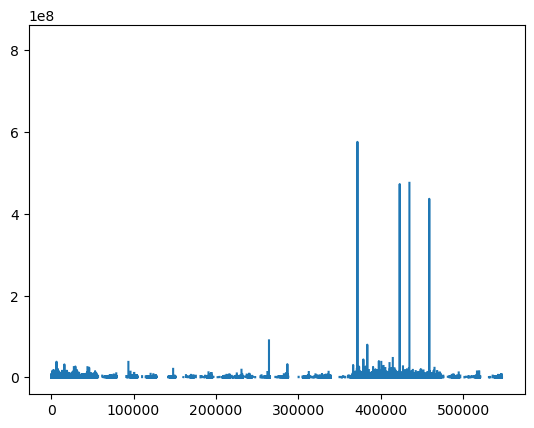

In [71]:
plt.plot(listings["ClosePrice"])